In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import re

What is the objective of this phase?
Produce a clean and well understood data set whihc only has english and hindi sms messages. there should be no duplicated records


In [5]:
df = pd.read_csv("../data/raw/dataset.csv")

In [6]:
print(df.head())

  labels                                               text     lang sentiment
0   spam  No 1 POLYPHONIC tone 4 ur mob every week! Just...  english  Positive
1   spam  Avez-vous entendu parler de la nouvelle "Divor...   french   Neutral
2    ham     हाय यह अच्छी तरह से जाने के लिए मेरा शुक्रिया!    hindi   Neutral
3    ham   Donc ça veut dire que tu penses toujours au teju   french  Negative
4   spam  Senden Sie ein Logo 2 ur Liebhaber - 2 Namen d...   german  Positive


In [7]:
print(df.shape)

(22287, 4)


In [8]:
print(df.columns)

Index(['labels', 'text', 'lang', 'sentiment'], dtype='str')


In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 22287 entries, 0 to 22286
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   labels     22287 non-null  str  
 1   text       22287 non-null  str  
 2   lang       22287 non-null  str  
 3   sentiment  22287 non-null  str  
dtypes: str(4)
memory usage: 696.6 KB
None


In [10]:
df.isnull().sum()

labels       0
text         0
lang         0
sentiment    0
dtype: int64

In [11]:
df.duplicated().sum()

1724

In [12]:
df['lang'].value_counts()

lang
french     5572
hindi      5572
german     5572
english    5571
Name: count, dtype: int64

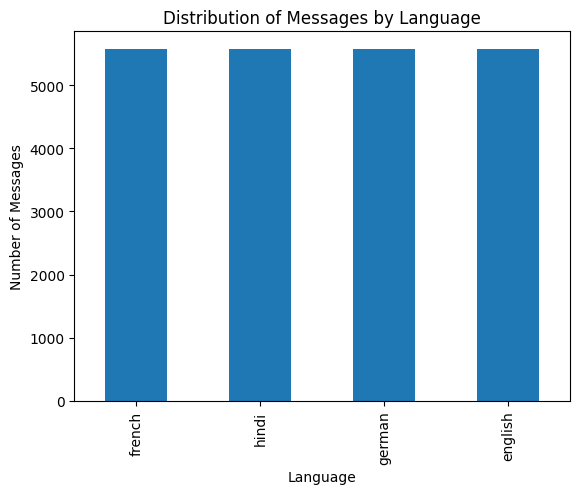

In [13]:
df['lang'].value_counts().plot(kind='bar')

plt.title("Distribution of Messages by Language")
plt.xlabel("Language")
plt.ylabel("Number of Messages")
plt.show()

In [14]:
df['labels'].value_counts()

labels
ham     19299
spam     2988
Name: count, dtype: int64

In [15]:
df['labels'].value_counts(normalize=True)*100

labels
ham     86.593081
spam    13.406919
Name: proportion, dtype: float64

accuracy may be misleading when the classes are imbalanced. the paper specifically discusses the problem fo underrepresented spam messages and the importancce of flase positives and false negatives

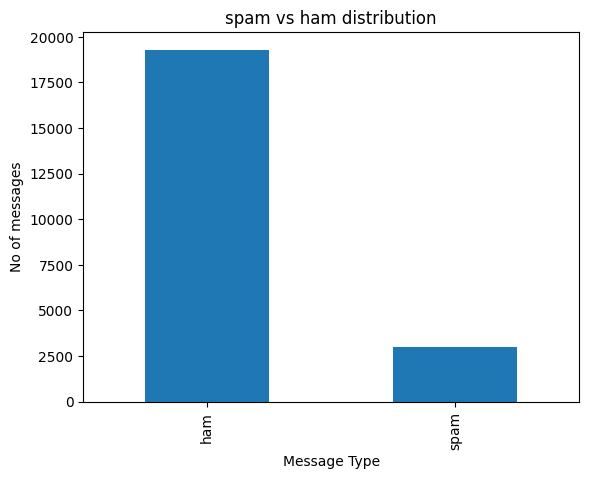

In [16]:
df['labels'].value_counts().plot(kind='bar')
plt.title("spam vs ham distribution")
plt.xlabel("Message Type")
plt.ylabel("No of messages")
plt.show()

checking language x label distribution

In [17]:
pd.crosstab(df['lang'],df['labels'])

labels,ham,spam
lang,,
english,4824,747
french,4825,747
german,4825,747
hindi,4825,747


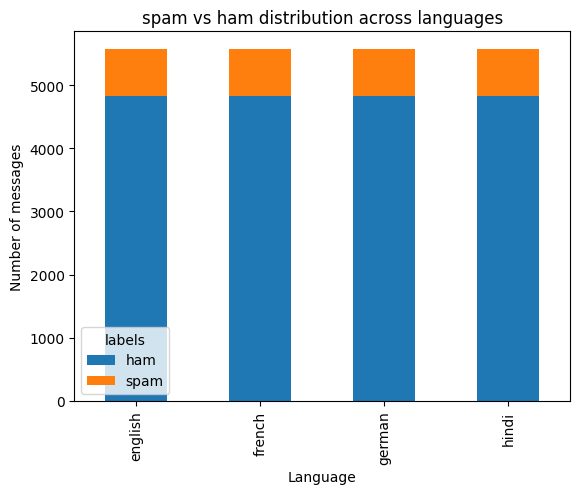

In [18]:
pd.crosstab(df['lang'], df['labels']).plot(kind='bar', stacked=True)

plt.title("spam vs ham distribution across languages")
plt.xlabel("Language")
plt.ylabel("Number of messages")
plt.show()

examining the duplicates

In [19]:
duplicates = df[df.duplicated(keep=False)]

duplicates.shape
duplicates.head(20)

,labels,text,lang,sentiment
0,spam,No 1 POLYPHONIC tone 4 ur mob every week! Just...,english,Positive
5,ham,"मैं तुम्हें बाद में फोन करता हूँ, नेटवर्क नहीं...",hindi,Neutral
9,spam,CURGERAN! आपके मोबाइल नंबर को 5 पाउंड इनाम GUR...,hindi,Neutral
10,spam,किसी ने हमारी डेटिंग सेवा से संपर्क किया है और...,hindi,Neutral
11,ham,वे क्या कर रहे हैं?,hindi,Neutral
14,ham,Gud mrng liebe hav einen schönen Tag,german,Neutral
24,ham,No calls..messages..missed calls,english,Negative
25,ham,Votre avis sur moi? 1. Plus de 2. Jada 3. Kusr...,french,Positive
33,ham,"aathi..wo bist du, Liebling..",german,Neutral
34,spam,Kamera - Sie erhalten eine SiPix Digitalkamera...,german,Neutral


In [20]:
message_label_counts = (df.groupby('text')['labels'].nunique())

conflicting_messages = message_label_counts[message_label_counts>1]

print("Messages with conflicting labels:", len(conflicting_messages))

Messages with conflicting labels: 0


In [21]:
#some random english data 

In [22]:
df[df['lang']=='english'].sample(10,random_state=42)

,labels,text,lang,sentiment
4561,ham,Hi darlin did youPhone me? Im atHome if youwan...,english,Neutral
2981,spam,U can WIN £100 of Music Gift Vouchers every we...,english,Positive
1825,spam,"Hi there, 2nights ur lucky night! Uve been inv...",english,Positive
4388,ham,And I don't plan on staying the night but I pr...,english,Neutral
19711,ham,No but the bluray player can,english,Negative
5681,ham,Hi dear we saw dear. We both are happy. Where ...,english,Positive
19109,ham,I jokin oni lar.. Ü busy then i wun disturb ü.,english,Negative
2387,ham,Good words.... But words may leave u in dismay...,english,Negative
893,ham,"I'm an actor. When i work, i work in the eveni...",english,Neutral
3588,ham,U horrible gal... U knew dat i was going out w...,english,Negative


In [23]:
df[df['lang']== 'hindi'].sample(10,random_state=42)

,labels,text,lang,sentiment
12974,ham,क्या आप पिताजी के साथ रहते हैं या अकेले रह रहे...,hindi,Neutral
3848,ham,कभी - कभी शांत और कोमल होता है ।,hindi,Neutral
4190,ham,"क्यों चुप हो जाओ, मैं गला घोंट रहा हूँ",hindi,Neutral
9931,spam,"HEVIN को 6985, 24Hrer मुक्त करने के लिए और फिर...",hindi,Neutral
3347,ham,के रूप में;#gt; एक ही सवाल,hindi,Neutral
11887,ham,मेरे लिए द डे रिपोर्ट की एक प्रति भेज सकते हैं?,hindi,Neutral
11947,ham,तुम्हारा भाई एक समझदार इंसान है,hindi,Neutral
11773,ham,मुझे एक आभासी गले भेजना चाहते हैं?,hindi,Neutral
898,spam,PRURRE GRANTC TANT TAS TE के लिए एक प्रशंसा या...,hindi,Neutral
4757,ham,किसी भी दिन मुक्त लेकिन मैं 6 पर समाप्त पर non...,hindi,Neutral


checking message length

In [24]:
df['message_length']=df['text'].str.len()
df['message_length'].describe()

count    22287.000000
mean        83.695203
std         66.708686
min          2.000000
25%         36.000000
50%         62.000000
75%        123.000000
max       1406.000000
Name: message_length, dtype: float64

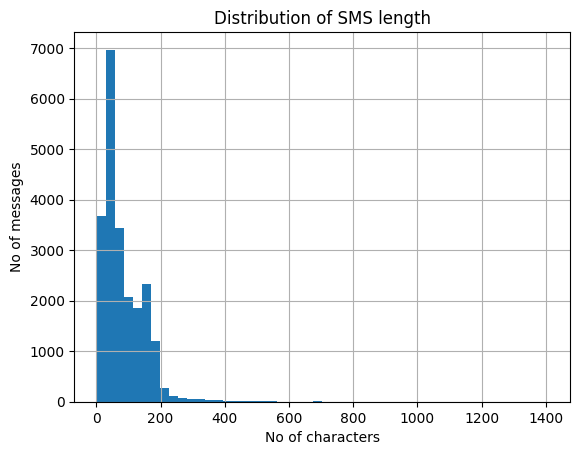

In [25]:
df['message_length'].hist(bins = 50)
plt.title("Distribution of SMS length")
plt.xlabel("No of characters")
plt.ylabel("No of messages")
plt.show()

In [26]:
df.groupby('labels')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
labels,,,,,,,,
ham,19299.0,74.628841,65.285314,2.0,34.0,53.0,96.0,1406.0
spam,2988.0,142.253347,41.280189,4.0,124.0,153.0,169.0,313.0


removing duplicates


In [27]:
print("Before:", len(df))
df= df.drop_duplicates()
print("After:",len(df))

Before: 22287
After: 20563


In [28]:
print("Duplicates remaining:", df.duplicated().sum())

Duplicates remaining: 0


In [29]:
# reseting the index
df = df.reset_index(drop = True)

In [30]:
duplicate_texts = (
    df[df.duplicated('text', keep=False)]
    .sort_values('text')
)

duplicate_texts[['text', 'labels', 'lang', 'sentiment', 'message_length']].head(30)

,text,labels,lang,sentiment,message_length
81,100 dating service cal;l 09064012103 box334sk38ch,spam,english,Neutral,49
8114,100 dating service cal;l 09064012103 box334sk38ch,spam,french,Neutral,49
3708,100 dating service cal;l 09064012103 box334sk38ch,spam,german,Neutral,49
16918,2/2 146tf150p,spam,english,Neutral,13
14164,2/2 146tf150p,spam,french,Neutral,13
6617,2/2 146tf150p,spam,german,Neutral,13
17501,645,ham,english,Neutral,3
20533,645,ham,hindi,Neutral,3
6117,:),ham,french,Positive,2
16280,:),ham,english,Positive,2


In [31]:
df_en_hin = df[df['lang'].isin(['english','hindi'])].copy()

In [32]:
df_en_hin.shape
df_en_hin['lang'].value_counts()
df_en_hin['labels'].value_counts()
pd.crosstab(df_en_hin['lang'], df_en_hin['labels'])

labels,ham,spam
lang,,
english,4515,641
hindi,4502,630


In [33]:
print("HINDI EXAMPLES")
display(
    df_en_hin[df_en_hin['lang'] == 'hindi']
    [['text', 'labels']]
    .sample(10, random_state=42)
)

HINDI EXAMPLES


,text,labels
20481,"हे भगवान, मैं लगभग घर पर हूँ",ham
8781,आप कृपया मुझे मेरी चाची की संख्या भेज सकते हैं,ham
10345,आप मुझे जगा करने के लिए माना जाता था &gt;: (i),ham
3403,"लुइस, आशा है कि आप उस तरह के दिन नहीं हो रहे हैं!",ham
5779,बर्गर राजा - वाना एक शीर्ष स्टेडियम में फुट लं...,spam
13081,"अगर मैं पूछूँ कि क्या हुआ है, तो आपको यह कहने ...",ham
15951,फ्रीएम: 1MATCHAN कॉल! स्मार्ट काल TV सक्रिय कर...,spam
19883,"मैं एक दर्द गले है, यह ress है जब मैं बात कर र...",ham
6239,खैर मैं एक चाची होने जा रहा हूँ!,ham
7015,"अरे, वह ठीक हो जाएगा. मुझे लगता है.",ham


In [34]:
df_en_hin['sentiment'].value_counts()
pd.crosstab(df_en_hin['labels'],df_en_hin['sentiment'])

sentiment,Negative,Neutral,Positive
labels,,,
ham,822,6140,2055
spam,91,710,470


In [35]:
print(df_en_hin['message_length'].describe())

count    10288.000000
mean        76.815513
std         59.906435
min          2.000000
25%         35.000000
50%         58.000000
75%        109.000000
max       1406.000000
Name: message_length, dtype: float64


In [36]:
print(df_en_hin['message_length'].describe())
print(
    df_en_hin.groupby('lang')['message_length'].describe()
)

count    10288.000000
mean        76.815513
std         59.906435
min          2.000000
25%         35.000000
50%         58.000000
75%        109.000000
max       1406.000000
Name: message_length, dtype: float64
          count       mean        std  min   25%   50%    75%     max
lang                                                                 
english  5156.0  79.051396  58.266529  2.0  36.0  61.0  118.0   910.0
hindi    5132.0  74.569174  61.433776  2.0  34.0  56.0  102.0  1406.0


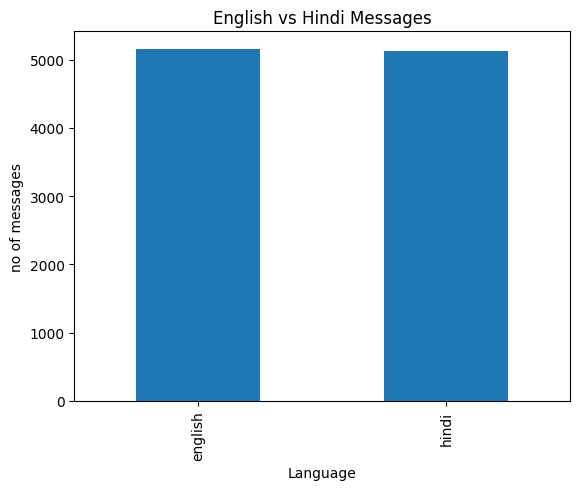

In [37]:
#english vs hindi
df_en_hin['lang'].value_counts().plot(kind='bar')
plt.title("English vs Hindi Messages")
plt.xlabel("Language")
plt.ylabel("no of messages")
plt.show()

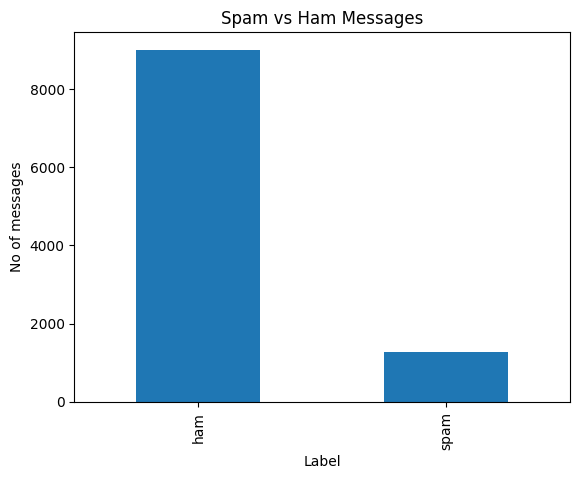

In [38]:
#spam vs ham
df_en_hin['labels'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Messages")
plt.xlabel("Label")
plt.ylabel("No of messages")
plt.show()

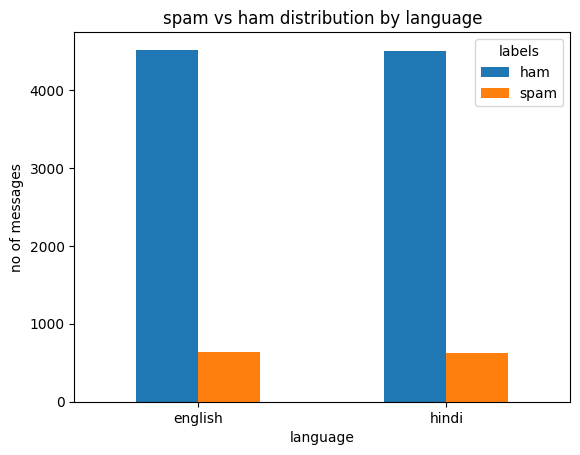

In [39]:
#spam/ham by languages
pd.crosstab(df_en_hin['lang'],df_en_hin['labels']).plot(kind ='bar')

plt.title("spam vs ham distribution by language")
plt.xlabel("language")
plt.ylabel("no of messages")
plt.xticks(rotation =0)
plt.show()

In [40]:
print(df_en_hin.shape)

print(df_en_hin['lang'].value_counts())

print(df_en_hin['labels'].value_counts())

print(pd.crosstab(df_en_hin['lang'], df_en_hin['labels']))

print(df_en_hin['sentiment'].value_counts())

(10288, 5)
lang
english    5156
hindi      5132
Name: count, dtype: int64
labels
ham     9017
spam    1271
Name: count, dtype: int64
labels    ham  spam
lang               
english  4515   641
hindi    4502   630
sentiment
Neutral     6850
Positive    2525
Negative     913
Name: count, dtype: int64


In [41]:
print(df_en_hin['message_length'].describe())

print(df_en_hin.groupby('labels')['message_length'].describe())

print(df_en_hin.groupby('lang')['message_length'].describe())

print(pd.crosstab(df_en_hin['labels'], df_en_hin['sentiment']))

count    10288.000000
mean        76.815513
std         59.906435
min          2.000000
25%         35.000000
50%         58.000000
75%        109.000000
max       1406.000000
Name: message_length, dtype: float64
         count        mean        std  min    25%    50%    75%     max
labels                                                                 
ham     9017.0   69.649994  58.655045  2.0   33.0   51.0   89.0  1406.0
spam    1271.0  127.650669  41.159426  4.0  106.0  140.0  156.0   313.0
          count       mean        std  min   25%   50%    75%     max
lang                                                                 
english  5156.0  79.051396  58.266529  2.0  36.0  61.0  118.0   910.0
hindi    5132.0  74.569174  61.433776  2.0  34.0  56.0  102.0  1406.0
sentiment  Negative  Neutral  Positive
labels                                
ham             822     6140      2055
spam             91      710       470


In [42]:
display(
    df_en_hin[df_en_hin['labels'] == 'spam']
    [['text', 'lang']]
    .sample(15, random_state=42)
)

,text,lang
20237,अरे मैं वास्तव में सींगी करना चाहता हूँ या मुझ...,hindi
18847,नवीनतम वीडियो कवर चाहते हो? 750 किसी भी बार कि...,hindi
6439,PRIVATE! Your 2003 Account Statement for 07808...,english
15595,YOU 07801543489 are guaranteed the latests Nok...,english
12613,"मैं कुछ मुर्गा चाहते हैं! मेरे मुख से दूर, मुझ...",hindi
12507,URGENT This is our 2nd attempt to contact U. Y...,english
328,Free Top ringtone -sub to weekly ringtone-get ...,english
6090,यह 2 सेकंड है जब हमने 2 संपर्क की कोशिश की है....,hindi
569,आपके पास 1 नया संदेश है. कृपया 0.87188034 का क...,hindi
8948,"आप किसी को पता है कि यह कौन है, पता करने के लि...",hindi


In [43]:
display(
    df_en_hin[df_en_hin['labels'] == 'ham']
    [['text', 'lang']]
    .sample(15, random_state=42)
)

,text,lang
11657,Hhaahahahahaghffag Naga अपने कमरे में या कुछ म...,hindi
13968,"सर, अपनी पत्र के लिए इंतजार कर रहे हैं.",hindi
3617,के.k: (k),hindi
1166,Have you heard about that job? I'm going to th...,english
14637,"Hyye, क्या यू ने मेरे खाते में पैसा उधार दे दि...",hindi
1758,मेरी सबसे बड़ी बात यह है कि हमारे सभी विभागों ...,hindi
7581,For many things its an antibiotic and it can b...,english
6193,"I av a new number, . Wil u only use this one,ta.",english
12180,Kent vale lor... Ü wait 4 me there ar?,english
5793,काम के बारे में अच्छी तरह सोचने के लिए अच्छी त...,hindi


In [44]:
''' For preprocessing:
We will: normalize whitespace, lowercase english text, preserve hindi unicode, preserve numbers, unseful punctuation intially, preserve urls, preserve currency symbols 
We will not: remove stop words, stem, lemmatize, remove numbers, remove punctuation, translate hinid to english

we want the first model to see the information that actually exists in the sms. later we'll experiment to determine whether removing some of these features improves performance
'''

" For preprocessing:\nWe will: normalize whitespace, lowercase english text, preserve hindi unicode, preserve numbers, unseful punctuation intially, preserve urls, preserve currency symbols \nWe will not: remove stop words, stem, lemmatize, remove numbers, remove punctuation, translate hinid to english\n\nwe want the first model to see the information that actually exists in the sms. later we'll experiment to determine whether removing some of these features improves performance\n"

In [45]:


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_en_hin['clean_text'] = df_en_hin['text'].apply(preprocess_text)

In [46]:
df_en_hin = df_en_hin.drop(15217).reset_index(drop=True)

In [47]:
df_en_hin = df_en_hin.reset_index(drop=True)

In [48]:
""" checking what preprocessing actually changed"""

' checking what preprocessing actually changed'

In [49]:
changed = (df_en_hin['text'] != df_en_hin['clean_text']).sum()
print("Messages changed: ", changed)
print("Messages unchanged: ", len(df_en_hin)- changed)

Messages changed:  6251
Messages unchanged:  4036


In [50]:
"""hindi is unicode. this data shoulnt be damaged"""
display(df_en_hin[df_en_hin['lang']== 'hindi'] [['text','clean_text']].sample(10,random_state = 42))

,text,clean_text
10247,"हे भगवान, मैं लगभग घर पर हूँ","हे भगवान, मैं लगभग घर पर हूँ"
4368,आप कृपया मुझे मेरी चाची की संख्या भेज सकते हैं,आप कृपया मुझे मेरी चाची की संख्या भेज सकते हैं
5165,आप मुझे जगा करने के लिए माना जाता था &gt;: (i),आप मुझे जगा करने के लिए माना जाता था &gt;: (i)
1709,"लुइस, आशा है कि आप उस तरह के दिन नहीं हो रहे हैं!","लुइस, आशा है कि आप उस तरह के दिन नहीं हो रहे हैं!"
2874,बर्गर राजा - वाना एक शीर्ष स्टेडियम में फुट लं...,बर्गर राजा - वाना एक शीर्ष स्टेडियम में फुट लं...
6526,"अगर मैं पूछूँ कि क्या हुआ है, तो आपको यह कहने ...","अगर मैं पूछूँ कि क्या हुआ है, तो आपको यह कहने ..."
7989,फ्रीएम: 1MATCHAN कॉल! स्मार्ट काल TV सक्रिय कर...,फ्रीएम: 1matchan कॉल! स्मार्ट काल tv सक्रिय कर...
9956,"मैं एक दर्द गले है, यह ress है जब मैं बात कर र...","मैं एक दर्द गले है, यह ress है जब मैं बात कर र..."
3100,खैर मैं एक चाची होने जा रहा हूँ!,खैर मैं एक चाची होने जा रहा हूँ!
3491,"अरे, वह ठीक हो जाएगा. मुझे लगता है.","अरे, वह ठीक हो जाएगा. मुझे लगता है."


In [51]:
""""""
df_en_hin.to_csv("../data/processed/english_hindi.csv", index = False)